In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\store_customers.csv")
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [2]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


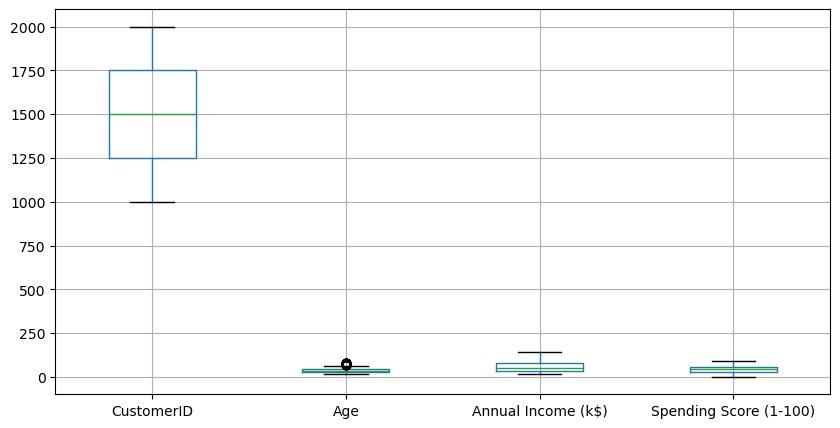

In [10]:
df.boxplot(figsize=(10,5))
plt.show()

In [11]:
q1=df['Age'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
print(q1)
print(q3)
print(iqr)
up=q3+1.5*iqr
lw=q1-1.5*iqr
print(up)
print(lw)

30.0
44.0
14.0
65.0
9.0


In [12]:
df['Age'].describe()

count    982.000000
mean      38.958248
std       13.417748
min       18.000000
25%       30.000000
50%       36.000000
75%       44.000000
max       80.000000
Name: Age, dtype: float64

In [13]:
out=df[(df['Age']>up) | (df['Age']<lw)]
print(out)

     CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
209        1209      F  66.0                98.9                     1.0
757        1757      F  76.0               125.5                     1.0
767        1767      F  66.0               108.2                     1.0
775        1775      M  69.0                91.8                     5.0
776        1776      M  68.0                95.7                    14.0
..          ...    ...   ...                 ...                     ...
982        1982      F  78.0               122.6                     1.0
983        1983      M  78.0               115.1                     1.0
991        1991      M  66.0               105.2                    12.0
995        1995      M  80.0               133.3                     1.0
999        1999      M  67.0               107.8                     1.0

[72 rows x 5 columns]


In [14]:
p=(len(out)/len(df)*100)
print('outliers%:',p)

outliers%: 7.3319755600814664


In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
label=LabelEncoder()

In [17]:
df['Gender']=label.fit_transform(df['Gender'])

In [18]:
df.drop('CustomerID',axis=1)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,39.0,59.9,58.0
1,1,34.0,48.4,37.0
2,0,40.0,70.5,26.0
3,0,47.0,81.1,30.0
4,0,33.0,42.1,58.0
...,...,...,...,...
995,1,80.0,133.3,1.0
996,1,44.0,82.6,40.0
997,0,46.0,67.7,26.0
998,0,28.0,45.7,59.0


In [19]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()

In [21]:
x=df[['Annual Income (k$)', 'Spending Score (1-100)']]
xs=scale.fit_transform(x)

In [23]:
from sklearn.cluster import KMeans

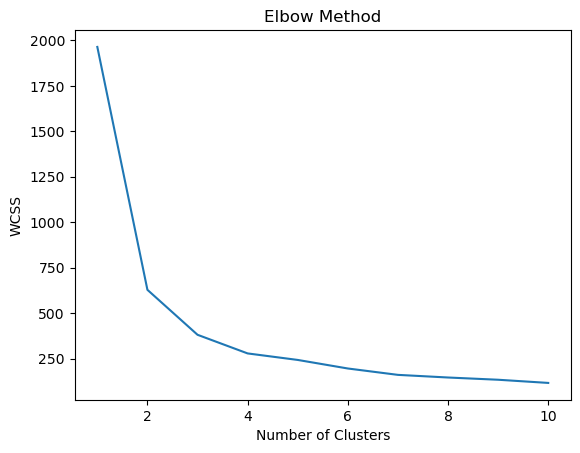

In [25]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(xs)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(xs)
df['Cluster'] = clusters

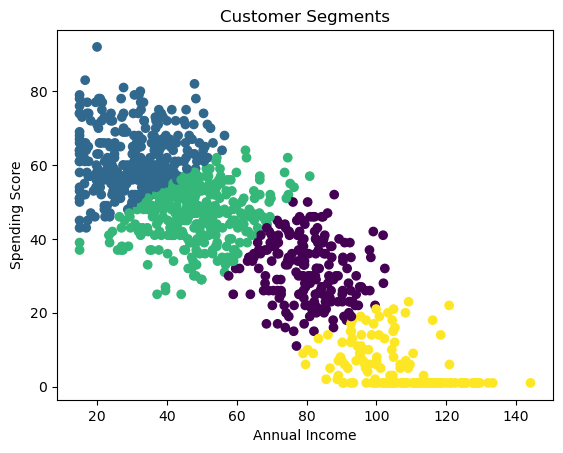

In [29]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

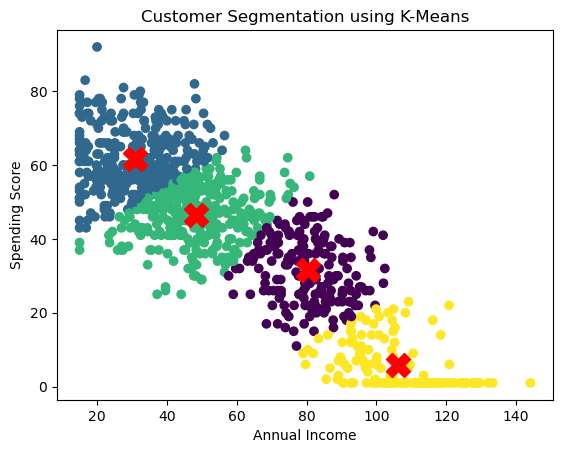

In [39]:
centers = scale.inverse_transform(kmeans.cluster_centers_)

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Cluster'])

plt.scatter(centers[:,0],
            centers[:,1],
            s=300, c='red', marker='X')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [6]:
cd Desktop/Customer-Segmentation-KMeans

[WinError 3] The system cannot find the path specified: 'Desktop/Customer-Segmentation-KMeans'
C:\Users\moham\ml
